In [2]:
import numpy as np
import pandas as pd 
import math 
import matplotlib.pyplot as plt 


In [ ]:
import numpy as np
import pandas as pd 
import math 


class IsingExperiment:

    def __init__(self, size, T, alpha=1.5,  mode="random", update_rule="bornholdt", seed=None, rng=None):
        self.size = size
        self.rng = rng if rng is not None else np.random.default_rng(seed)
        self.mode = mode
        self.update_rule = update_rule
        self.seed = seed
        self.T = T  # temperature, can be varied to see how it affects volatility and crashes
        self.h = 0.0  # external field, set to 0 for now but can be used to simulate interest rates or other external factors
        self.J = 1.0  # coupling constant, set to 1 for simplicity but can be varied to simulate different market conditions
        self.alpha = alpha  # Bornholdt feedback strength, can be tuned to see how it affects volatility and crashes
        self.spins = self.create_grid()

    def create_grid(self): 
        #creates an nxn numpy grid and initialises random parameters 


        if self.mode == "random":
            spins = self.rng.choice([-1,1],size=(self.size,self.size))
        elif self.mode == "up":
            spins = np.ones((self.size,self.size), dtype=int)
        elif self.mode == "down":
            spins = -np.ones((self.size,self.size), dtype=int)
        else:
            raise ValueError("Mode must be: up, random, down")

        return spins

    # COMPUTE ENERGY AND BOUNDARY CONDITIONS (HAMILTONIAN): 

    def total_energy(self): 

        #computes periodic boundary conditions (wraps around)
        right = np.roll(self.spins, shift=-1, axis=1)
        down = np.roll(self.spins, shift=-1, axis=0)

        interaction = -self.J * np.sum(self.spins * (right + down))
        field_term = -self.h * np.sum(self.spins)

        return interaction + field_term
        
    # CALCULATE CHANGE IN ENERGY BY CHANGING ONE SPIN

    def delta_energy_Bornholdt(self, i, j): 

        L = self.size
        s = self.spins[i, j]

        # periodic neighbours
        up    = self.spins[(i - 1) % L, j]
        down  = self.spins[(i + 1) % L, j]
        left  = self.spins[i, (j - 1) % L]
        right = self.spins[i, (j + 1) % L]

        abs_m = np.abs(np.mean(self.spins))   # global magnetisation

        S = up + down + left + right

        return 2 * s * (self.J * S + self.h) - (2 * self.alpha * abs_m )


    def delta_energy(self, i, j): 

        L = self.size
        s = self.spins[i, j]

        # periodic neighbours
        up    = self.spins[(i - 1) % L, j]
        down  = self.spins[(i + 1) % L, j]
        left  = self.spins[i, (j - 1) % L]
        right = self.spins[i, (j + 1) % L]

        S = up + down + left + right

        return 2 * s * (self.J * S + self.h)

    # CALCULATE MAGNETISATION

    def magnetisation(self):
        return np.mean(self.spins)

    # RUN ONE METROPOLIS SWEEP (LxL)

    def metropolis_sweep(self, T=2.0): 
        rng = self.rng

        L = self.size
        N = self.size * self.size

        for _ in range(N):
            i = rng.integers(0, L)
            j = rng.integers(0, L)

            if self.update_rule == "ising":
                dE = self.delta_energy(i, j)
            elif self.update_rule == "bornholdt":
                dE = self.delta_energy_Bornholdt(i, j)
            else:
                raise ValueError("update_rule must be 'ising' or 'bornholdt'")

            if dE <= 0:
                self.spins[i, j] *= -1
            else:
                if rng.random() < np.exp(-dE /T):
                    self.spins[i, j] *= -1

        return self.spins

    # RUN ONE HEATBATH SWEEP WITH BORNHOLDT LOCAL FIELD

    def heatbath_sweep_bornholdt(self, T=2.0, alpha=0.1):
        N = self.size * self.size
        for _ in range(N):
            i = self.rng.integers(0, self.size)
            j = self.rng.integers(0, self.size)

            s = self.spins[i, j]

            # periodic neighbours
            up    = self.spins[(i - 1) % self.size, j]
            down  = self.spins[(i + 1) % self.size, j]
            left  = self.spins[i, (j - 1) % self.size]
            right = self.spins[i, (j + 1) % self.size]

            nn_sum = up + down + left + right

            # global magnetisation
            m = np.mean(self.spins)

            # Bornholdt local field
            local_field = self.J * nn_sum - alpha * s * abs(m) + self.h

            # Heat-bath probability of setting spin to +1
            p_plus = 1.0 / (1.0 + np.exp(-2.0 * local_field / T))

            self.spins[i, j] = 1 if self.rng.random() < p_plus else -1

        return self.spins

    # GET ROLLING VOLATILITY FROM RETURNS

    def rolling_volatility(self, r, window=10):
        vol = np.full(len(r),np.nan)
        
        for t in range(window, len(r)):
            window_data = r[t-window:t]   # ONLY past values
            vol[t] = np.std(window_data)
            
        return vol

    #GET NON-ROLLING VOL FROM RETURNS

    def non_overlapping_volatility(self, r, window=10, ddof=1):
        r = np.asarray(r)
        
        n_blocks = len(r) // window
        trimmed = r[:n_blocks * window]              # drop leftover values
        blocks = trimmed.reshape(n_blocks, window)   # shape = (n_blocks, window)
        
        vol = np.std(blocks, axis=1, ddof=ddof)
        return vol


    def autocorrelation_function(self, x, max_lag):
        x = np.asarray(x)
        x = x - np.mean(x)
        N = len(x)
        
        acf = np.zeros(max_lag + 1)
        
        var = np.var(x)
        
        for tau in range(max_lag + 1):
            cov = np.sum(x[:N - tau] * x[tau:]) / (N - tau)
            acf[tau] = cov / var
            
        return acf

    # RUN SIMULATION METROPOLIS SWEEPS, COLLECT MAGNETISATION, ENERGY, RETURNS, VOLATILITY

    def run_single_simulation(self,
    n_equil=1000,
    n_steps=1500,
    sample_freq=10,
    T=2.0,
):
        L = self.size
      
        print(f"[T={T}] Initialising lattice...")
    

        print(f"[T={T}] Running equilibration sweeps ({n_equil})...")
        for i in range(n_equil):
            self.metropolis_sweep(T=T)

        print(f"[T={self.T}] Starting main simulation ({n_steps} steps)...")

        mags = []
        energies = []
        first_returns = []

        # define 4 checkpoints for progress updates
        checkpoints = set([
            int(n_steps * 0.25),
            int(n_steps * 0.5),
            int(n_steps * 0.75),
            int(n_steps * 1.0)
        ])

        for i in range(n_steps):
            self.metropolis_sweep(T)

            if i % sample_freq == 0:
                current_mags = float(self.magnetisation())

                if len(mags) > 0:
                    first_returns.append(float(current_mags - mags[-1]))


                energies.append(self.total_energy())
                mags.append(current_mags)

            # clean progress updates (~4 total)
            if (i + 1) in checkpoints:
                progress = int(((i + 1) / n_steps) * 100)
                print(f"[T={self.T}] Progress: {progress}%")

        print(f"[T={self.T}] Simulation complete.\n")

        mags = np.array(mags)
        abs_mags = np.array(mags)
        first_returns = np.array(first_returns)

        rolling_vol = self.rolling_volatility(first_returns, window=10) if len(first_returns) >= 10 else np.array([])
        block_vol = self.non_overlapping_volatility(first_returns, window=10, ddof=1) if len(first_returns) >= 10 else np.array([])

        
        acf_m = self.autocorrelation_function(mags, 50)
        acf_r = self.autocorrelation_function(first_returns, 50)
        acf_abs_r = self.autocorrelation_function(np.abs(first_returns), 50)
        acf_rolling_vol = self.autocorrelation_function(rolling_vol, 50)
        acf_sq_r = self.autocorrelation_function(first_returns**2, 50)
        acf_block_vol = self.autocorrelation_function(block_vol, 50)

        average_mag = np.mean(mags)
        abs_average_mag = np.mean(np.abs(mags))
        susceptibility = L**2/T*(np.mean(mags**2)-average_mag**2)
        heat_capacity = 1/(L**2 * T**2) * (np.mean(energies**2) - np.mean(energies)**2)
        u4 = 1 - (np.mean(mags**4)/(3*np.mean(mags**2)**2))

        return {
            "Temperature": self.T,
            "Magnetisation": mags,
            "Abs_Magnetisation": abs_mags,
            "First_Return": first_returns,
            "Abs_Return": np.abs(first_returns),
            "Squared_Return": first_returns**2,
            "Rolling_Vol": rolling_vol,
            "Non_Rol_Vol": block_vol,
            "acf_m": acf_m,
            "acf_r": acf_r,
            "acf_abs_r": acf_abs_r,
            "acf_rolling_vol": acf_rolling_vol,
            "acf_sq_r": acf_sq_r,
            "acf_block_vol": acf_block_vol,
            "Average_Magnetisation": average_mag,  
            "Abs_Average_Magnetisation": abs_average_mag,
            "Susceptibility": susceptibility,
            "Heat_Capacity": heat_capacity,
            "Binder_Cumulant": u4
    }

    def run_single_simulation_heatbath(self,
    n_equil=5000,
    n_steps=50000,
    sample_freq=10,
    T=2.0,
    alpha=0.1
):
        L = self.size
       

        print(f"[T={T}], [a={alpha}] Initialising lattice...")
    

        print(f"[T={T}], [a={alpha}] Running equilibration sweeps ({n_equil})...")
        for i in range(n_equil):
            self.heatbath_sweep_bornholdt(T=T, alpha=alpha)

        print(f"[T={T}], [a={alpha}] Starting main simulation ({n_steps} steps)...")

        mags = []
        first_returns = []

        checkpoints = set([
            int(n_steps * 0.25),
            int(n_steps * 0.5),
            int(n_steps * 0.75),
            int(n_steps * 1.0)
        ])

        for i in range(n_steps):
           self.heatbath_sweep_bornholdt(T=T, alpha=alpha)

           if i % sample_freq == 0:
                current_mags = float(self.magnetisation())
                mags.append(current_mags)
                abs_mags.append(abs(current_mags))

                if len(mags) > 1:
                    first_returns.append(float(mags[-1] - mags[-2]))

           if (i + 1) in checkpoints:
                pct = int(100 * (i + 1) / n_steps)
                print(f"[T={T}] {pct}% complete...")

        mags = np.array(mags)
        abs_mags = np.array(abs_mags)
        first_returns = np.array(first_returns)

        rolling_vol = self.rolling_volatility(first_returns, window=10) if len(first_returns) >= 10 else np.array([])
        block_vol = self.non_overlapping_volatility(first_returns, window=10, ddof=1) if len(first_returns) >= 10 else np.array([])

        acf_m = self.autocorrelation_function(mags, 50)
        acf_r = self.autocorrelation_function(first_returns, 50)
        acf_abs_r = self.autocorrelation_function(np.abs(first_returns), 50)
        acf_rolling_vol = self.autocorrelation_function(rolling_vol, 50)
        acf_sq_r = self.autocorrelation_function(sq_r, 50)
        acf_block_vol = self.autocorrelation_function(block_vol, 50)


        return {
            "Temperature": T,
            "Alpha": alpha,
            "Magnetisation": mags,
            "First_Return": first_returns,
            "Abs_Magnetisation": abs_mags,
            "Abs_Return": np.abs(first_returns),
            "Squared_Return": first_returns**2,
            "Rolling_Vol": rolling_vol,
            "Non_Rol_Vol": block_vol,
            "acf_m": acf_m,
            "acf_r": acf_r,
            "acf_abs_r": acf_abs_r,
            "acf_rolling_vol": acf_rolling_vol,
            "acf_sq_r": acf_sq_r,
            "acf_block_vol": acf_block_vol
    }

    def run_simulation_heatbath(self, n_equil=20000, n_steps=50000, sample_freq=1):
        results = {}
        for t in self.T:

            results[t] = {}
            for alpha in self.alphas:
                self.spins = self.create_grid()  # reset lattice before each run
                results[t][alpha] = self.run_single_simulation_heatbath(
                    n_equil=n_equil,
                    n_steps=n_steps,
                    sample_freq=sample_freq,
                    T = t,
                    alpha = alpha
                )

        return results
    
    def run_simulation_metropolis(self, n_equil=20000, n_steps=50000, sample_freq=1):
        
        results = {}
        for t in self.T:
            results[t] = {}
            for alpha in self.alphas:
                self.spins = self.create_grid()  # reset lattice before each run
                results[t][alpha] = self.run_single_simulation(
                    n_equil=n_equil,
                    n_steps=n_steps,
                    sample_freq=sample_freq,
                    T = t,
                )
    
    def run_grid(self, n_equil=20000, n_steps=50000, sample_freq=1):
        if self.update_rule == "ising":
            return self.run_simulation_metropolis(n_equil=n_equil, n_steps=n_steps, sample_freq=sample_freq)
        elif self.update_rule == "bornholdt":
            return self.run_simulation_heatbath(n_equil=n_equil, n_steps=n_steps, sample_freq=sample_freq)
        else:
            raise ValueError("update_rule must be 'ising' or 'bornholdt'")


            
               

In [ ]:
#RUN THE HEATBATH SIMULATION AT SEVERAL TEMPERATURES AND EXTRACT BASIC METRICS:

temps = [1.5,4]
alphas = [0.1, 0.5, 1.0]
model = IsingModel(size=50, T=temps, alpha=alphas, mode="random", update_rule="bornholdt", seed=42)
results = model.run_simulation_heatbath()

[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (50000 steps)...
[T=1.5] 25% complete...
[T=1.5] 50% complete...
[T=1.5] 75% complete...
[T=1.5] 100% complete...
[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (50000 steps)...
[T=1.5] 25% complete...
[T=1.5] 50% complete...
[T=1.5] 75% complete...
[T=1.5] 100% complete...
[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (50000 steps)...
[T=1.5] 25% complete...
[T=1.5] 50% complete...
[T=1.5] 75% complete...
[T=1.5] 100% complete...
[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (50000 steps)...
[T=1.5] 25% complete...
[T=1.5] 50% complete...
[T=1.5] 75% complete...
[T=1.5] 100% complete...
[T=4] Initialising lattice...
[T=4] Running equilibration sweeps (20000)...
[T=4] Starting m

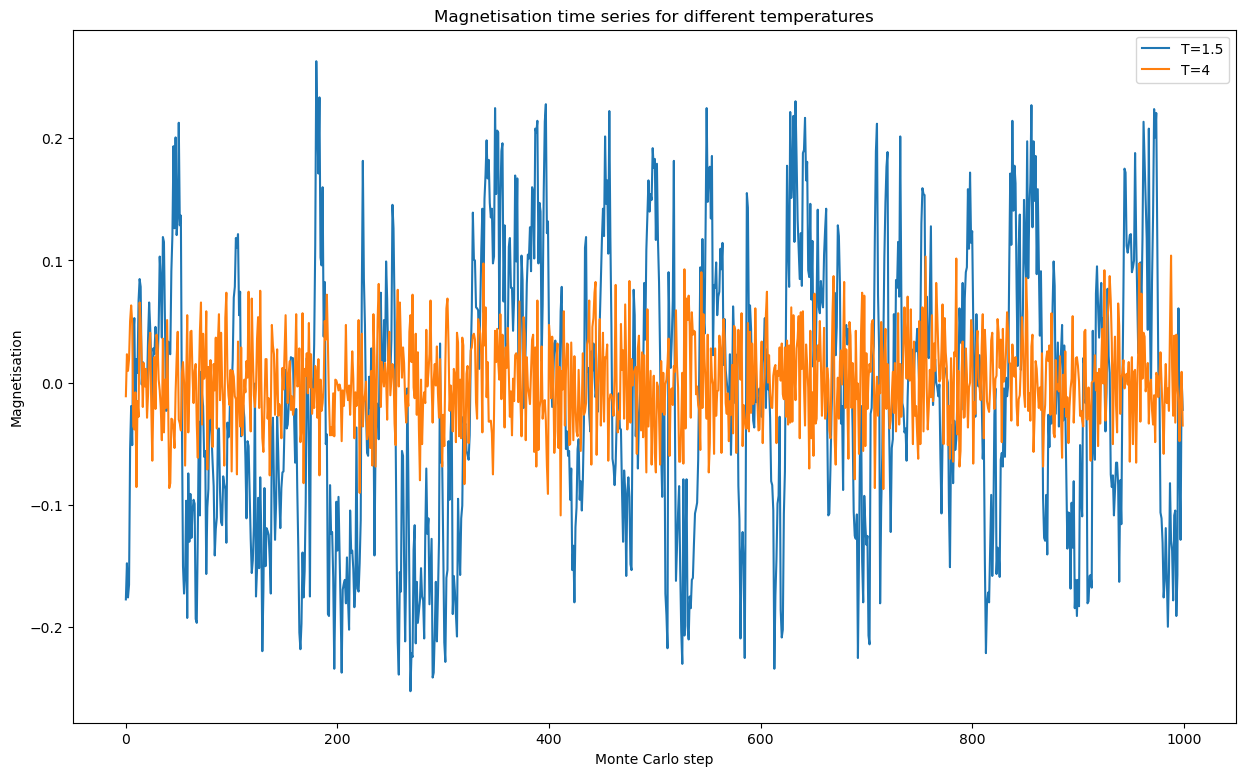

In [15]:
#PLOT MAGNETISATION (MARKET SENTIMENT) AT DIFFERENT TEMPERATURES 

plot_t = [1.5,4]


def plot_amount(arr,num=100):
    size = arr.size
    if size >= 100:
        sampled_val = int(size/num)
    else:
        sampled_val = 1

    return sampled_val 
 

plt.figure(figsize=(15, 9))
for t in plot_t:
    sampled_val = plot_amount(results[t][4]["Magnetisation"],1000)  
    plt.plot(results[t][6]["Magnetisation"][::sampled_val], label=f"T={t}")
plt.xlabel("Monte Carlo step")
plt.ylabel("Magnetisation")
plt.title("Magnetisation time series for different temperatures")
plt.legend()
plt.show()


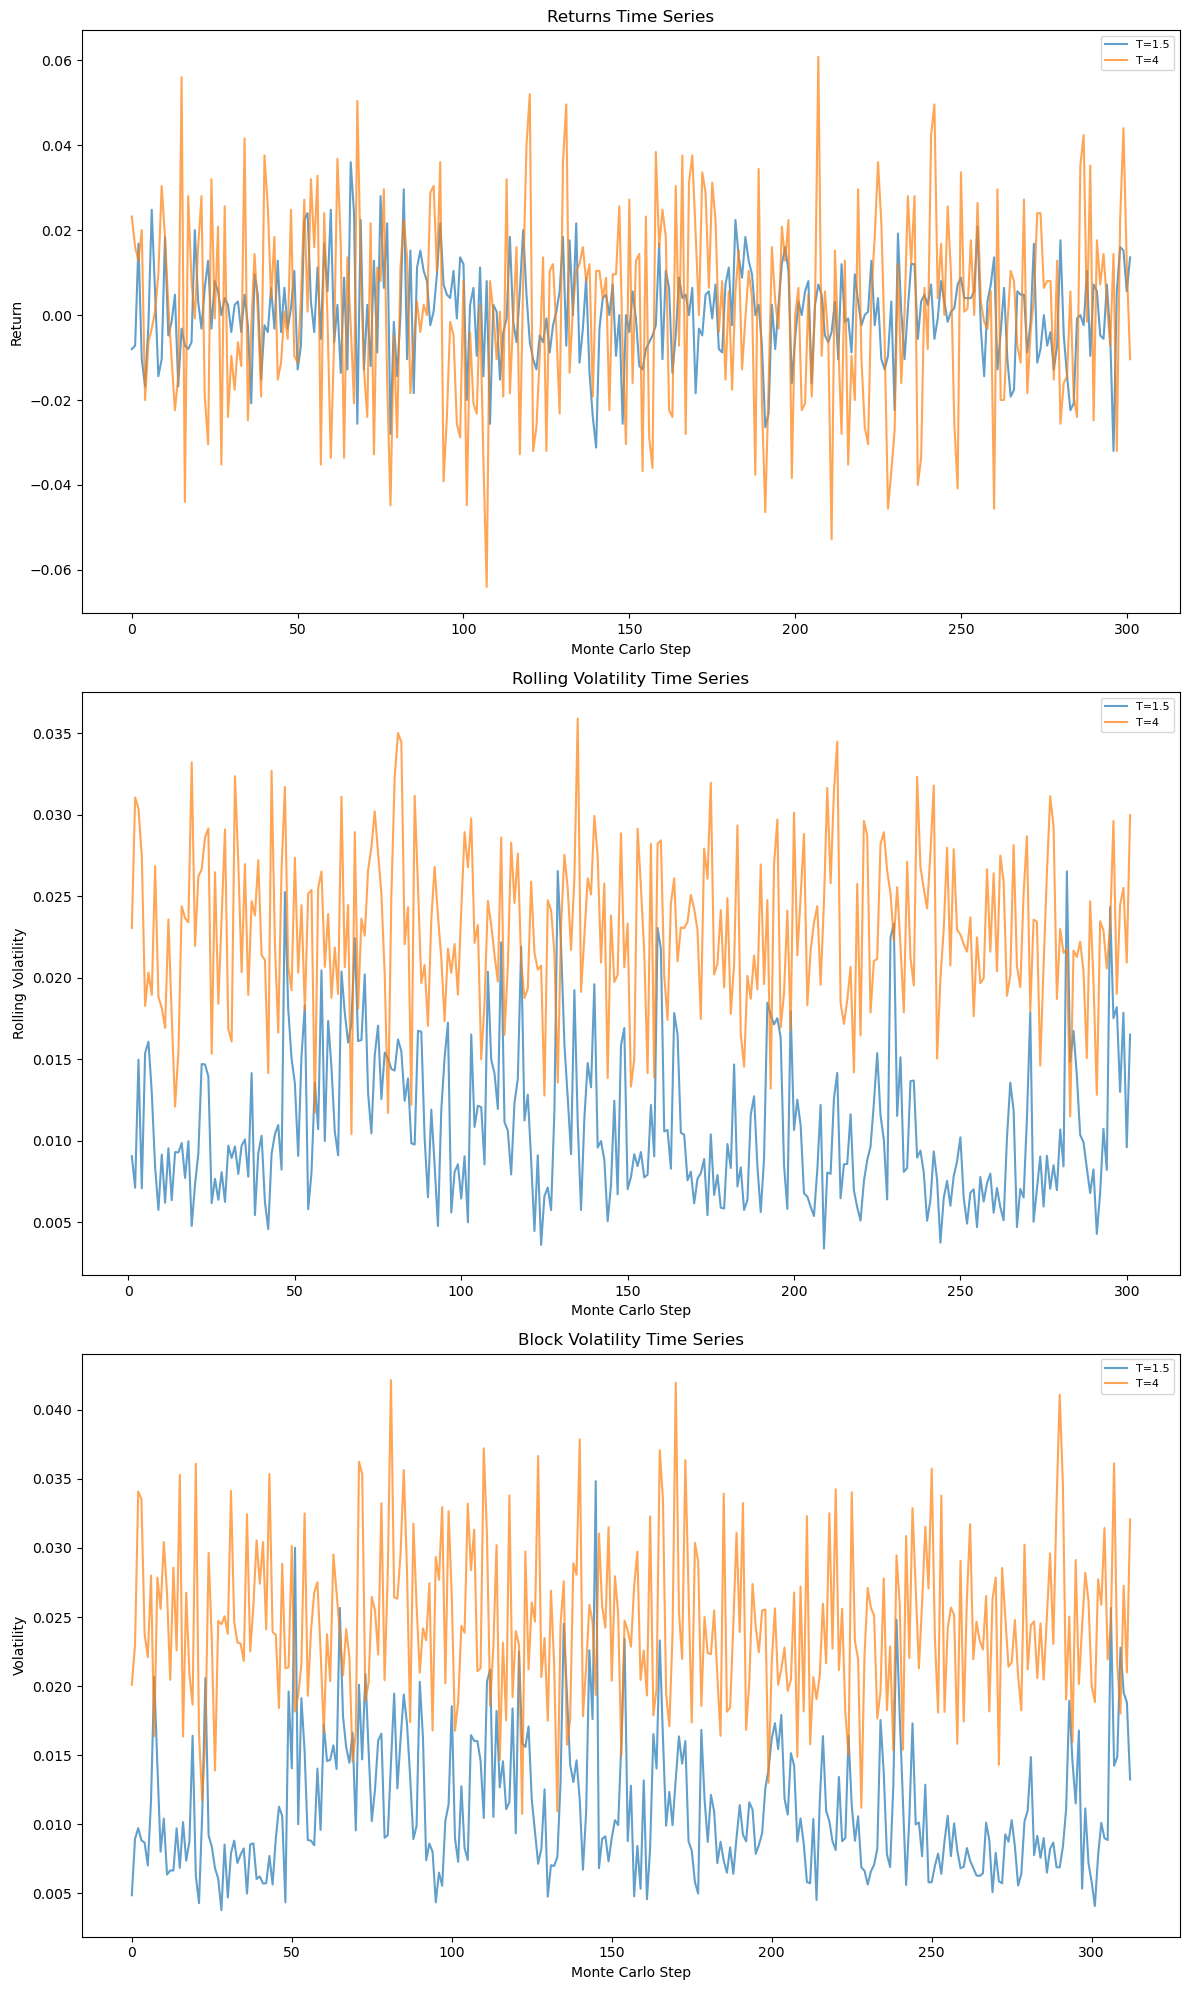

In [ ]:


fig, axes = plt.subplots(3, 1, figsize=(12, 20))

# Left: Returns
sampled_val = plot_amount(results[t][4]["First_Return"],300)  
for t in plot_t:
    axes[0].plot(results[t][4]["First_Return"][::sampled_val], alpha=0.7, label=f"T={t}")
axes[0].set_title("Returns Time Series")
axes[0].set_xlabel("Monte Carlo Step")
axes[0].set_ylabel("Return")
axes[0].legend(fontsize=8)

# Right: Rolling Volatility
sampled_val = plot_amount(results[t][4]["Rolling_Vol"],300)  
for t in plot_t:
    axes[1].plot(results[t][4]["Rolling_Vol"][::sampled_val], alpha=0.7, label=f"T={t}")
axes[1].set_title("Rolling Volatility Time Series")
axes[1].set_xlabel("Monte Carlo Step")
axes[1].set_ylabel("Rolling Volatility")
axes[1].legend(fontsize=8)

sampled_val = plot_amount(results[t][4]["Non_Rol_Vol"],300)  
for t in plot_t:
    axes[2].plot(results[t][4]["Non_Rol_Vol"][::sampled_val], alpha=0.7, label=f"T={t}")
axes[2].set_title("Block Volatility Time Series")
axes[2].set_xlabel("Monte Carlo Step")
axes[2].set_ylabel("Volatility")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

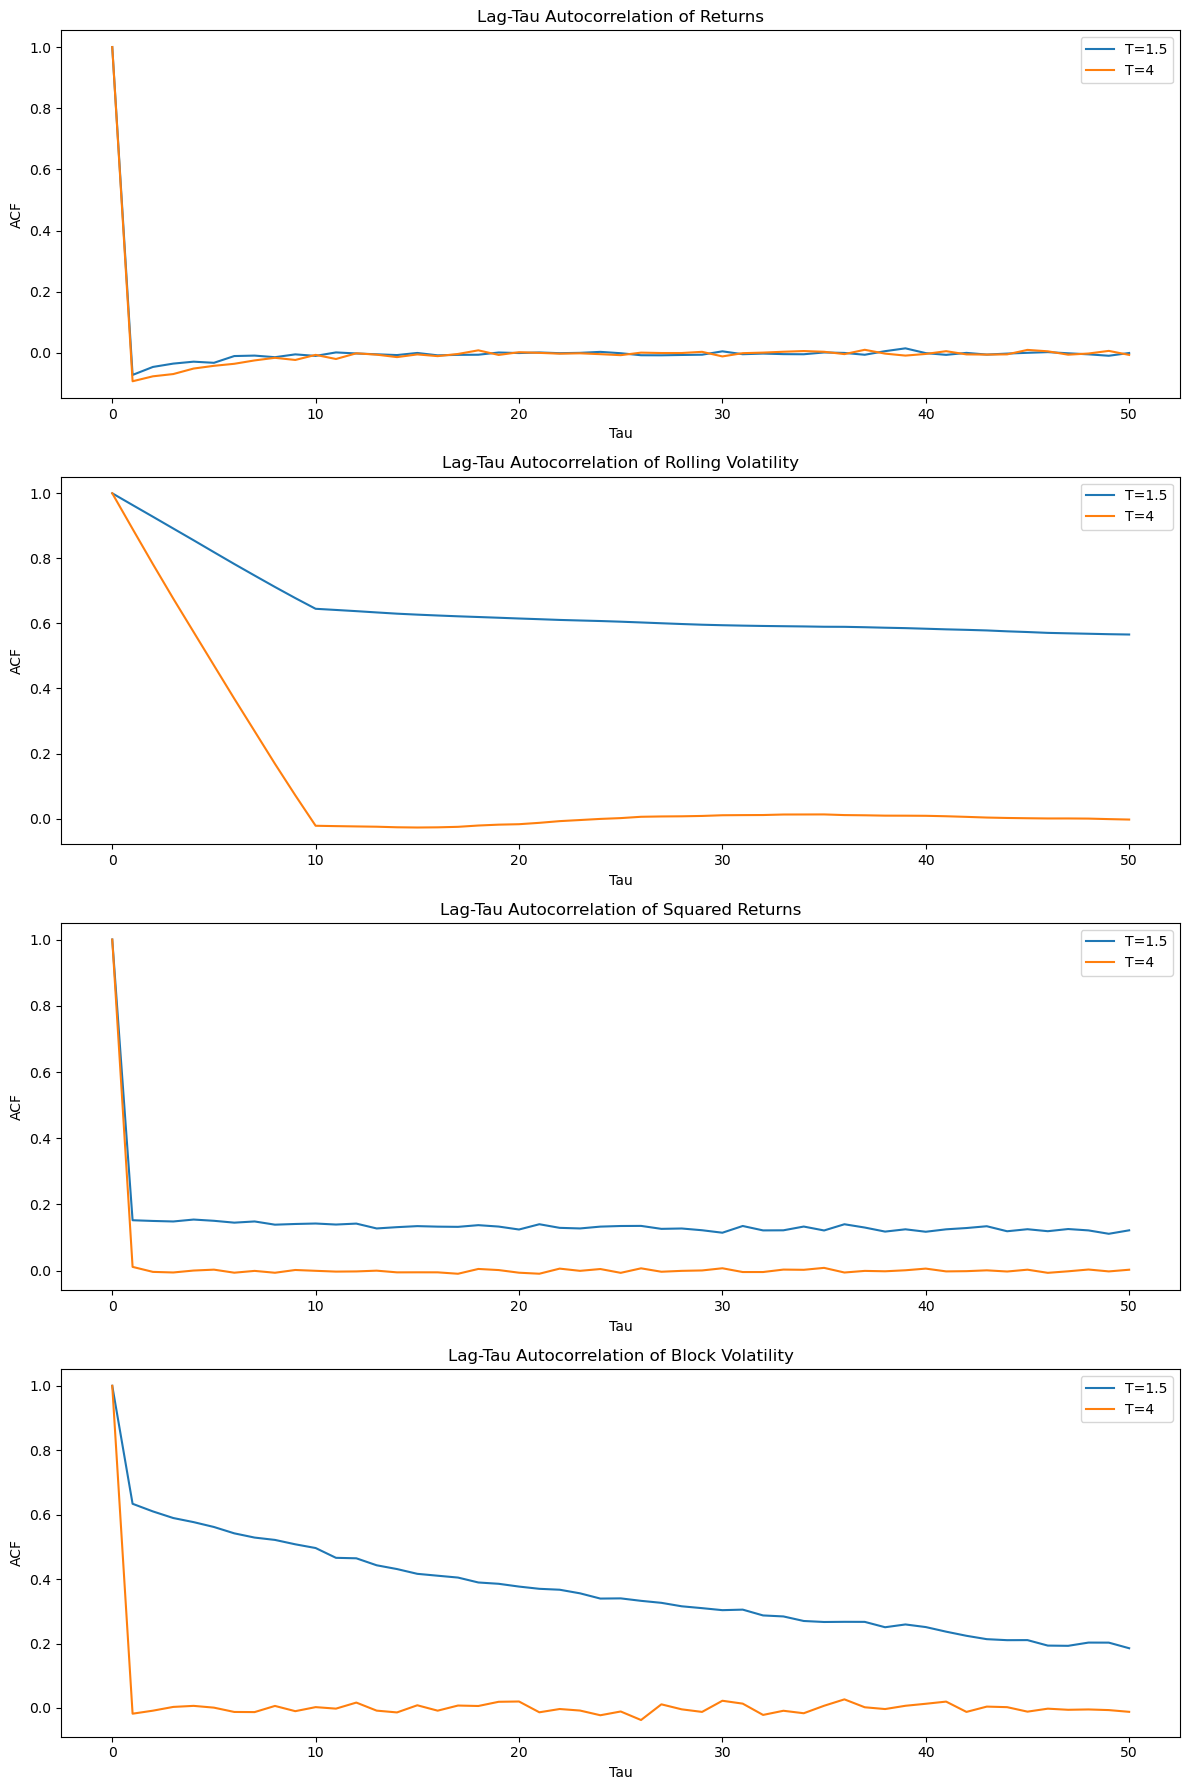

In [ ]:
#COMPUTE AND PLOT ACF (mag,returns,abs return), CORRELATION TIME, KURTOSIS


#calculate lag-Tau auto-correlation for Tau up to max_lag

def autocorrelation_function(x, max_lag):
    x = np.asarray(x)
    x = x - np.mean(x)
    N = len(x)
    
    acf = np.zeros(max_lag + 1)
    
    var = np.var(x)
    
    for tau in range(max_lag + 1):
        cov = np.sum(x[:N - tau] * x[tau:]) / (N - tau)
        acf[tau] = cov / var
        
    return acf

acf = {}

for t in temps:
    m = np.array(results[t][4]["Magnetisation"])  # downsample for faster ACF calculation
    r = np.array(results[t][4]["First_Return"])
    abs_r = np.abs(r)
    sq_r = r**2
    rolling_vol_val = np.array(results[t][4 ]["Rolling_Vol"])
    rolling_vol_val = rolling_vol_val[~np.isnan(rolling_vol_val)] # remove NAN values from rolling vol_val so autocorrelation works 
    block_vol_val = np.array(results[t][4]["Non_Rol_Vol"])


    acf_m = autocorrelation_function(m, 50)
    acf_r = autocorrelation_function(r, 50)
    acf_abs_r = autocorrelation_function(abs_r, 50)
    acf_rolling_vol = autocorrelation_function(rolling_vol_val, 50)
    acf_sq_r = autocorrelation_function(sq_r, 50)
    acf_block_vol = autocorrelation_function(block_vol_val, 50)

    acf[t] = {"acf_m":acf_m,"acf_r":acf_r,"acf_abs_r":acf_abs_r ,"acf_rolling_vol":acf_rolling_vol, "acf_sq_r": acf_sq_r, "acf_block_vol": acf_block_vol }


#Plot AutoCorrelation values for Tau

fig, axes = plt.subplots(4, 1, figsize=(12, 18))
axes = axes.flatten()



for t in plot_t:
    axes[0].plot(acf[t]["acf_r"], label=f"T={t}")
    axes[1].plot(acf[t]["acf_rolling_vol"], label=f"T={t}")
    axes[2].plot(acf[t]["acf_sq_r"], label=f"T={t}")
    axes[3].plot(acf[t]["acf_block_vol"], label=f"T={t}")


axes[0].set_xlabel("Tau")
axes[0].set_ylabel("ACF")
axes[0].set_title("Lag-Tau Autocorrelation of Returns")
axes[0].legend()

axes[1].set_xlabel("Tau")
axes[1].set_ylabel("ACF")
axes[1].set_title("Lag-Tau Autocorrelation of Rolling Volatility")
axes[1].legend()

axes[2].set_xlabel("Tau")
axes[2].set_ylabel("ACF")
axes[2].set_title("Lag-Tau Autocorrelation of Squared Returns")
axes[2].legend()

axes[3].set_xlabel("Tau")
axes[3].set_ylabel("ACF")
axes[3].set_title("Lag-Tau Autocorrelation of Block Volatility")
axes[3].legend()

plt.tight_layout()
plt.show()

